# Fig 1 — Whitening QQ plot

This figure validates the whitening step. Under the isotropic Gaussian null the timing residuals $d_I$ at the $N_p$ pulsars are correlated by the response covariance $R_{IJ}$ (in the $fD\to\infty$ limit, the Hellings--Downs curve). We compute KS $p$-values against the unit-scale $\mathrm{Exp}(1)$ reference for (i) the raw diagonal powers $|d_I|^2/R_{II}$ and (ii) the whitened diagonal powers $|w_I|^2$, with $w_I=(\Lambda^{-1/2}M^\dagger)_{IK}\,d_K$ from the eigendecomposition of $R_{IJ}$, and show their $p$-value distributions as a QQ plot.

Without whitening the inter-pulsar correlations make the test reject spuriously (the blue curve departs from the diagonal); after whitening with $R$ the data are decorrelated and the curve tracks the uniform diagonal, as expected under $H_0$. This confirms that whitening is what makes the single-epoch KS test well calibrated.

## How to use this notebook
If you have downloaded this notebook from the repo set `REGENERATE_DATA = True` to recompute the data. It will be saved as `data/fig1_whitening.npz`.

If you want to save the plot (it is saved under `plots/fig1_whitening.pdf`), set `SAVE_PLOT` to True.

In [1]:
REGENERATE_DATA = False
SAVE_PLOT = True

In [2]:
from pathlib import Path

import healpy as hp
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

import jax
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp

import fastPTA.data.generate_data as gd
from fastPTA import utils as ut
from fastPTA.data import datastream as gds

from helpers.pta_helpers import set_paper_rcparams

DATA_PATH = Path('data') / 'fig1_whitening.npz'
PLOT_PATH = Path('plots') / 'fig1_whitening.pdf'
PLOT_PATH.parent.mkdir(parents=True, exist_ok=True)
DATA_PATH.parent.mkdir(parents=True, exist_ok=True)

NP = 67
NSIDE = 16
N_REAL = 1000
F_HZ = 1.0 / (16.03 * 365.25 * 86400.0)
SEED = 7

## Compute or load p-values

In [3]:
def compute_pvalues(np_pulsars=NP, nside=NSIDE, n_real=N_REAL,
                    f_hz=F_HZ, seed=SEED):
    npix = hp.nside2npix(nside)
    fcenter = np.array([f_hz])

    p_vec, _, distances, theta_k, phi_k = gd.generate_pulsar_sky_and_kpixels(
        np_pulsars, Nside=nside)
    distances = np.array(distances) * ut.parsec

    R_p, R_c = gds.get_R_pc(jnp.asarray(fcenter), distances, p_vec,
                            theta_k, phi_k)
    Rp0 = np.array(R_p[..., 0])
    Rc0 = np.array(R_c[..., 0])

    R0 = (Rp0 @ Rp0.conj().T + Rc0 @ Rc0.conj().T) / npix
    R0 = 0.5 * (R0 + R0.conj().T)
    e_vals, e_vecs = np.linalg.eigh(R0)
    e_vals = np.maximum(e_vals, 1e-15)
    W_mat = (e_vecs * (1.0 / np.sqrt(e_vals))).conj().T

    diag_R0 = np.diag(R0).real
    inv_sqrtNpix = 1.0 / np.sqrt(npix)
    rng = np.random.default_rng(seed)

    pvals_raw = np.empty(n_real)
    pvals_white = np.empty(n_real)
    for i in range(n_real):
        h_plus = (rng.standard_normal(npix)
                  + 1j * rng.standard_normal(npix)) / np.sqrt(2)
        h_cross = (rng.standard_normal(npix)
                   + 1j * rng.standard_normal(npix)) / np.sqrt(2)
        d = inv_sqrtNpix * (Rp0 @ h_plus + Rc0 @ h_cross)
        w = W_mat @ d
        pvals_raw[i] = stats.kstest(np.abs(d) ** 2 / diag_R0, 'expon').pvalue
        pvals_white[i] = stats.kstest(np.abs(w) ** 2, 'expon').pvalue
    return pvals_raw, pvals_white

In [4]:
if REGENERATE_DATA or not DATA_PATH.exists():
    print(f'Computing {N_REAL} realizations ...')
    pvals_raw, pvals_white = compute_pvalues()
    np.savez(DATA_PATH,
             pvals_raw=pvals_raw, pvals_white=pvals_white,
             Np=NP, n_real=N_REAL)
    print(f'Saved {DATA_PATH}')
else:
    data = np.load(DATA_PATH)
    pvals_raw = data['pvals_raw']
    pvals_white = data['pvals_white']
    n_real = int(data['n_real'])
    print(f'Loaded {DATA_PATH} (n_real = {n_real})')

Loaded data/fig1_whitening.npz (n_real = 1000)


## QQ plot

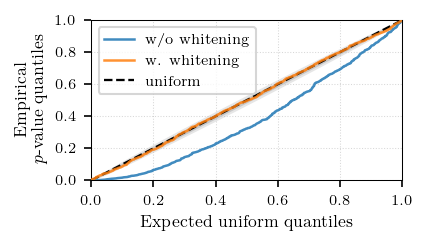

Saved plots/fig1_whitening.pdf


In [5]:
from scipy.stats import beta

use_tex, COLUMN_W, _ = set_paper_rcparams()

pvals_raw_sorted = np.sort(pvals_raw)
pvals_white_sorted = np.sort(pvals_white)
n = len(pvals_raw_sorted)
q = (np.arange(1, n + 1) - 0.5) / n
i = np.arange(1, n + 1)
lo95 = beta.ppf(0.025, i, n + 1 - i)
hi95 = beta.ppf(0.975, i, n + 1 - i)
lo68 = beta.ppf(0.16, i, n + 1 - i)
hi68 = beta.ppf(0.84, i, n + 1 - i)

fig, ax = plt.subplots(figsize=(0.85*COLUMN_W, 0.7*2.4))
band95 = ax.fill_between(q, lo95, hi95, color='0.90', lw=0, zorder=1,
                         label=(r'95\% CI' if use_tex else '95% CI'))
band68 = ax.fill_between(q, lo68, hi68, color='0.78', lw=0, zorder=2,
                         label=(r'68\% CI' if use_tex else '68% CI'))
line_raw,   = ax.plot(q, pvals_raw_sorted,   color='C0', lw=1.2, alpha=0.85,
                      zorder=4, label='w/o whitening')
line_white, = ax.plot(q, pvals_white_sorted, color='C1', lw=1.2, alpha=0.85,
                      zorder=5, label='w. whitening')
line_exp,   = ax.plot([0, 1], [0, 1], 'k--', lw=1.1, zorder=3,
                      label='uniform')

ax.set_xlabel('Expected uniform quantiles')
ax.set_ylabel('Empirical\n$p$-value quantiles' if use_tex
              else 'Empirical p-value quantiles')
ax.grid(True, which='both', ls=':', lw=0.5, alpha=0.5)
ax.legend(handles=[line_raw, line_white, line_exp], # , band68, band95
          loc='upper left')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
fig.tight_layout()
plt.show()

if SAVE_PLOT:
    fig.savefig(PLOT_PATH)
    print(f'Saved {PLOT_PATH}')